In [1]:
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import pandas as pd

In [3]:
df = pd.read_excel(r"D:\UCM\Curso 4\Resultados\Exploratorio\Base_Final_Depurada.xlsx")
edad = df["Edad"] 
dependiente = df["Est_Salud"]

In [4]:
modelo1=df
modelo2=df
modelo3=df
modelo4=df
modelo5=df

In [5]:
df.head()

,CCAA,Genero,Edad,Pais_Nac,Convivencia,Est_Civil,Tipo_Hogar,N_Adultos,N_Menores,Niv_Estud,...,P_Diabetes,P_Digestivo,P_Mental,P_Ictus,P_Migraña,P_Cutaneo,P_Osteoporosis,P_LesAccid,P_Cancer,P_Bucodental
0,País Vasco,Hombre,75,España,Ninguno,Soltero,Unipersonal,1,0,FP grado medio,...,No,Sí,No,No,No,No,No,No,No,No
1,País Vasco,Mujer,96,España,Ninguno,Viudo,Unipersonal,1,0,Primaria completa,...,No,Sí,No,No,Sí,Sí,Sí,No,No,No
2,País Vasco,Mujer,74,España,Ninguno,Viudo,Unipersonal,1,0,Primaria completa,...,Sí,Sí,No,No,No,No,Sí,No,No,No
3,País Vasco,Mujer,79,España,Cónyuge,Casado,Pareja sola,2,0,Primaria completa,...,Sí,Sí,No,No,No,Sí,No,No,No,No
4,País Vasco,Hombre,70,Extranjero,Cónyuge,Casado,Pareja sola,2,0,Primaria completa,...,No,No,No,No,No,No,No,No,No,No


In [6]:
import prince
import pandas as pd
import matplotlib.pyplot as plt

def famd_scree(df, target=None, n_components=10, random_state=42, plot=True, save_path=None):
    """
    Parámetros:
    -----------
    df : DataFrame
    target : str or None
        Variable dependiente a eliminar
    n_components : int
        Componentes para exploración
    random_state : int
    plot : bool
    """

    # 1. PREPARACIÓN
    df_used = df.copy()

    if target is not None and target in df_used.columns:
        df_used = df_used.drop(columns=[target])

    # 2. FAMD
    famd = prince.FAMD(
        n_components=n_components,
        n_iter=3,
        random_state=random_state
    )

    famd = famd.fit(df_used)

    print("Eigenvalues:")
    print(famd.eigenvalues_)

    # 3. SCREE PLOT
    if plot:
        plt.figure()
        plt.plot(famd.eigenvalues_, marker='o')
        plt.xlabel("Componentes")
        plt.ylabel("Autovalor")
        plt.title("Scree plot - FAMD")

        if save_path is not None:
            plt.savefig(save_path, dpi=300, bbox_inches='tight')

        plt.show()

    return famd, df_used

Eigenvalues:
[159.91050711  96.1218705   73.75931445  59.90455984  53.72886652
  46.97091986  42.97316486  40.21301995  38.11418021  34.36486992]


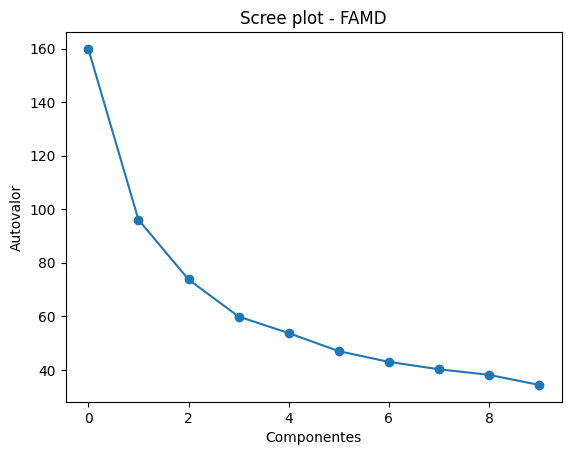

In [7]:
famd, df_used = famd_scree(
    df=modelo1,
    target="Est_Salud",
    n_components=10,
    save_path="scree_plot_famd_ev1.png"
)

In [8]:
import prince
import pandas as pd
import matplotlib.pyplot as plt


def top_variables(loadings, component, top_n=10):
    return (
        loadings.iloc[:, component]
        .abs()
        .sort_values(ascending=False)
        .head(top_n)
        .to_frame(name=f"Componente {component}")
    )


def famd_final(df, n_components=3, target=None, random_state=42, show=True):   

    # 1. PREPARACIÓN
    df_used = df.copy()

    if target is not None and target in df_used.columns:
        df_used = df_used.drop(columns=[target])

    # 2. MODELO FAMD
    famd = prince.FAMD(
        n_components=n_components,
        n_iter=3,
        random_state=random_state
    )

    famd = famd.fit(df_used)


    # 3. COORDENADAS
    ind_coords = famd.row_coordinates(df_used)
    var_coords = famd.column_coordinates_


    # 4. TABLA GLOBAL
    tabla_global = var_coords.iloc[:, :n_components].copy()
    tabla_global["importance"] = tabla_global.abs().sum(axis=1)
    tabla_global = tabla_global.sort_values("importance", ascending=False)


    # 5. TOP VARIABLES POR COMPONENTE
    top_vars = {}
    for i in range(n_components):
        top_vars[f"Componente {i}"] = top_variables(var_coords, i)


    # 6. OUTPUT
    if show:
        print("\n" + "="*60)
        print("FAMD EJECUTADO CORRECTAMENTE")
        print("="*60)

        print("\nVARIANZA EXPLICADA:")
        print(famd.eigenvalues_summary)

        print("\nTABLA GLOBAL (TOP 15 VARIABLES):")
        display(tabla_global.head(15))

        print("\nTOP VARIABLES POR COMPONENTE:")

        for k, v in top_vars.items():
            print("\n" + k)
            display(v)

        print("\nCOORDENADAS INDIVIDUOS (preview):")
        display(ind_coords.head())

    return {
        "famd": famd,
        "ind_coords": ind_coords,
        "var_coords": var_coords,
        "tabla_global": tabla_global,
        "top_variables": top_vars,
        "df_used": df_used
    }

In [9]:
result = famd_final(
    df=modelo1,
    n_components=10,
    target="Est_Salud"
)


FAMD EJECUTADO CORRECTAMENTE

VARIANZA EXPLICADA:
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0            159.911         2.73%                      2.73%
1             96.122         1.64%                      4.37%
2             73.759         1.26%                      5.63%
3             59.905         1.02%                      6.66%
4             53.729         0.92%                      7.58%
5             46.971         0.80%                      8.38%
6             42.973         0.73%                      9.11%
7             40.213         0.69%                      9.80%
8             38.114         0.65%                     10.45%
9             34.365         0.59%                     11.04%

TABLA GLOBAL (TOP 15 VARIABLES):


component,0,1,2,3,4,5,6,7,8,9,importance
variable,,,,,,,,,,,
Edad,0.513542,0.122133,0.299020,0.348679,0.067165,0.252735,0.213028,0.201878,0.161879,0.192374,2.372433
Tipo_Hogar,0.198322,0.719595,0.223832,0.182621,0.057508,0.232445,0.113426,0.257759,0.148674,0.058034,2.192216
N_Adultos,0.098828,0.602802,0.072462,0.049302,0.033598,0.313266,0.036440,0.296064,0.077914,0.036172,1.616847
Est_Civil,0.271185,0.685356,0.191143,0.102006,0.021857,0.067847,0.122341,0.033333,0.048988,0.005356,1.549411
Niv_Estud,0.132582,0.016169,0.147168,0.059707,0.329878,0.024553,0.058182,0.053413,0.032584,0.186915,1.041150
Convivencia,0.020266,0.771511,0.089201,0.016919,0.013856,0.025482,0.008700,0.043953,0.002499,0.016771,1.009159
CCAA,0.025983,0.028573,0.056018,0.047954,0.086007,0.027973,0.192325,0.132715,0.315111,0.076659,0.989320
Frec_Cuidado_Mayores,0.002730,0.040113,0.063684,0.314774,0.003921,0.240144,0.127708,0.100600,0.004857,0.005366,0.903897
Cuidado_Mayores,0.001122,0.040443,0.061574,0.314646,0.000004,0.236874,0.126004,0.099695,0.004416,0.000270,0.885049



TOP VARIABLES POR COMPONENTE:

Componente 0


,Componente 0
variable,
Edad,0.513542
Dolor,0.402959
D_Caminar,0.400078
P_Osteoarticular,0.372512
P_Digestivo,0.305607
D_Concentrar,0.292932
P_cardiovascular,0.286481
Est_Civil,0.271185
P_Cutaneo,0.265488



Componente 1


...

,Componente 8
variable,
CCAA,0.315111
Estrato,0.273229
Edad,0.161879
Tipo_Hogar,0.148674
N_Menores,0.122339
Sev_Depresiva,0.090636
N_Adultos,0.077914
Est_Civil,0.048988
Veces_Medico_4s,0.042256



Componente 9


,Componente 9
variable,
Edad,0.192374
Niv_Estud,0.186915
Clase_Social,0.134523
Genero,0.105279
CCAA,0.076659
Tabaco,0.075690
Exp_Humo,0.065121
Act_Jornada,0.061826
Tipo_Hogar,0.058034



COORDENADAS INDIVIDUOS (preview):


component,0,1,2,3,4,5,6,7,8,9
0,4.629359,-8.439489,-4.415522,-7.074416,-7.243478,-0.889310,-7.029519,-2.777526,-0.396985,-1.350115
1,37.486019,-12.556625,0.593223,16.826946,-5.866056,6.267471,3.075962,3.189344,-5.519881,-5.905061
2,16.950076,-11.094626,-15.237721,-2.828617,-7.214990,-0.169808,1.722041,-6.055233,-7.847545,-10.462859
3,7.328815,7.687724,-17.398901,1.095789,-4.944769,2.050870,-5.579659,3.512859,-1.690471,-9.275788
4,-5.466090,8.227625,-15.382743,-1.781760,-3.695302,-0.764006,-7.065636,4.609829,-1.296283,-3.115099


In [10]:
P_cardio_metab = ["P_cardiovascular","P_Venoso", "P_Ictus","P_Diabetes"]
P_musculo_esq = ["P_Osteoarticular","P_Osteoporosis","P_LesAccid"]
P_organicas = ["P_Respiratorio","P_Digestivo","P_Cancer"]
P_neuro_mental = ["P_Mental","P_Migraña"]
P_otros = ["P_Cutaneo","P_Bucodental"]

def agrupar_binario(df, nombre_nueva, columnas):
    df[nombre_nueva] = (
        df[columnas].eq("Sí").any(axis=1)
    ).map({True: "Sí", False: "No"})
    
    return df

modelo2 = agrupar_binario(modelo2, "P_cardio_metab", P_cardio_metab)
modelo2 = agrupar_binario(modelo2, "P_musculo_esq", P_musculo_esq)
modelo2 = agrupar_binario(modelo2, "P_organicas", P_organicas)
modelo2 = agrupar_binario(modelo2, "P_neuro_mental", P_neuro_mental)
modelo2 = agrupar_binario(modelo2, "P_otros", P_otros)

cols_nuevas = ["P_cardio_metab", "P_musculo_esq", "P_organicas","P_neuro_mental","P_otros"]
modelo2 = modelo2.drop(columns=[
    col for col in df.columns
    if col.startswith("P_") 
    and col not in cols_nuevas
    and col != "P_Entorno"
])

In [11]:
modelo2.head()

,CCAA,Genero,Edad,Pais_Nac,Convivencia,Est_Civil,Tipo_Hogar,N_Adultos,N_Menores,Niv_Estud,...,Urgencias_Util,Veces_Medico_4s,Cuidado_Mayores,Frec_Cuidado_Mayores,Dolor,P_cardio_metab,P_musculo_esq,P_organicas,P_neuro_mental,P_otros
0,País Vasco,Hombre,75,España,Ninguno,Soltero,Unipersonal,1,0,FP grado medio,...,No,0,No,0,Leve,Sí,Sí,Sí,No,No
1,País Vasco,Mujer,96,España,Ninguno,Viudo,Unipersonal,1,0,Primaria completa,...,No,1,No,0,Moderado,Sí,Sí,Sí,Sí,Sí
2,País Vasco,Mujer,74,España,Ninguno,Viudo,Unipersonal,1,0,Primaria completa,...,No,0,No,0,Leve,Sí,Sí,Sí,No,No
3,País Vasco,Mujer,79,España,Cónyuge,Casado,Pareja sola,2,0,Primaria completa,...,No,1,No,0,Ninguno,Sí,No,Sí,No,Sí
4,País Vasco,Hombre,70,Extranjero,Cónyuge,Casado,Pareja sola,2,0,Primaria completa,...,No,0,No,0,Ninguno,Sí,No,No,No,No


Eigenvalues:
[113.64110135  78.22781812  56.44096566  49.85311753  44.81776689
  39.20013826  34.80990321  32.25516789  31.16860731  28.44280928]


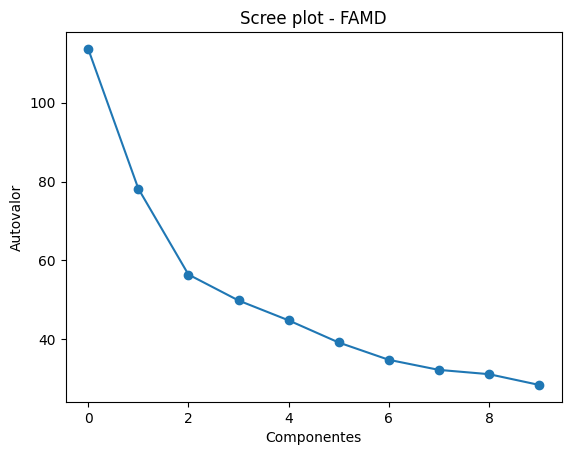

In [12]:
famd, df_used = famd_scree(
    df=modelo2,
    target="Est_Salud",
    n_components=10,
    save_path="scree_plot_famd_ev2.png"
)

In [13]:
result = famd_final(
    df=modelo2,
    n_components=10,
    target="Est_Salud"
)


FAMD EJECUTADO CORRECTAMENTE

VARIANZA EXPLICADA:
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0            113.641         2.46%                      2.46%
1             78.228         1.69%                      4.16%
2             56.441         1.22%                      5.38%
3             49.853         1.08%                      6.46%
4             44.818         0.97%                      7.43%
5             39.200         0.85%                      8.28%
6             34.810         0.75%                      9.03%
7             32.255         0.70%                      9.73%
8             31.169         0.68%                     10.41%
9             28.443         0.62%                     11.02%

TABLA GLOBAL (TOP 15 VARIABLES):


component,0,1,2,3,4,5,6,7,8,9,importance
variable,,,,,,,,,,,
Edad,0.513435,0.122928,0.294951,0.341103,0.077729,0.230153,0.235546,0.171152,0.168195,0.198105,2.353297
Tipo_Hogar,0.231992,0.707203,0.237208,0.215039,0.051108,0.251739,0.227438,0.101173,0.249499,0.072611,2.345009
N_Adultos,0.127286,0.589738,0.087924,0.081943,0.029559,0.281258,0.065337,0.061148,0.225521,0.043982,1.593696
Est_Civil,0.292627,0.682346,0.180812,0.103035,0.028761,0.058278,0.129062,0.021717,0.061311,0.008166,1.566115
Niv_Estud,0.139010,0.014409,0.157200,0.055310,0.333563,0.030452,0.031523,0.064685,0.017096,0.230809,1.074057
CCAA,0.026071,0.029649,0.062589,0.050952,0.084702,0.013203,0.077730,0.386211,0.154053,0.154472,1.039632
Convivencia,0.035399,0.771248,0.076648,0.017789,0.010603,0.029328,0.007661,0.009032,0.035908,0.009498,1.003115
Frec_Cuidado_Mayores,0.002389,0.039758,0.080497,0.257635,0.018479,0.285781,0.155391,0.015033,0.064655,0.010174,0.929792
Cuidado_Mayores,0.000813,0.040061,0.077271,0.258542,0.011343,0.279752,0.153254,0.013291,0.062350,0.002472,0.899149



TOP VARIABLES POR COMPONENTE:

Componente 0


,Componente 0
variable,
Edad,0.513435
D_Caminar,0.408459
Dolor,0.399197
P_musculo_esq,0.374373
P_cardio_metab,0.345526
D_Concentrar,0.300623
Est_Civil,0.292627
P_organicas,0.244368
Tipo_Hogar,0.231992



Componente 1


...

,Componente 8
variable,
Tipo_Hogar,0.249499
N_Adultos,0.225521
Edad,0.168195
CCAA,0.154053
Estrato,0.105721
Frec_Cuidado_Mayores,0.064655
Cuidado_Mayores,0.062350
Est_Civil,0.061311
Alimentacion,0.041674



Componente 9


,Componente 9
variable,
Niv_Estud,0.230809
Edad,0.198105
Clase_Social,0.165228
CCAA,0.154472
Tabaco,0.097731
Ingresos,0.080859
Estrato,0.078138
Tipo_Hogar,0.072611
Exp_Humo,0.071382



COORDENADAS INDIVIDUOS (preview):


component,0,1,2,3,4,5,6,7,8,9
0,3.475241,7.641110,-3.197260,-7.380699,5.578992,2.752574,3.561783,-1.860836,-5.084353,-7.761095
1,31.228135,9.893823,1.119037,14.928726,3.152010,-2.248984,-2.809544,-14.485192,-9.005475,-11.192962
2,10.007255,9.383043,-12.681991,-4.273081,5.224316,0.196249,-3.525892,1.299239,-7.689209,-4.951254
3,1.447478,-6.761543,-12.553281,0.156618,6.330264,-0.306022,1.075407,-4.453092,1.770865,-7.653547
4,-4.795000,-7.959207,-13.509874,-2.372351,3.376355,0.990858,3.647803,-3.605738,0.059829,-4.994001


In [14]:
modelo3=modelo2
modelo3 = modelo3.drop(columns=[
    "Edad"
])

In [15]:
modelo3.head()

,CCAA,Genero,Pais_Nac,Convivencia,Est_Civil,Tipo_Hogar,N_Adultos,N_Menores,Niv_Estud,Clase_Social,...,Urgencias_Util,Veces_Medico_4s,Cuidado_Mayores,Frec_Cuidado_Mayores,Dolor,P_cardio_metab,P_musculo_esq,P_organicas,P_neuro_mental,P_otros
0,País Vasco,Hombre,España,Ninguno,Soltero,Unipersonal,1,0,FP grado medio,Trabajadores cualificados (sector primario)/Se...,...,No,0,No,0,Leve,Sí,Sí,Sí,No,No
1,País Vasco,Mujer,España,Ninguno,Viudo,Unipersonal,1,0,Primaria completa,Ocupaciones intermedias/Autónomos,...,No,1,No,0,Moderado,Sí,Sí,Sí,Sí,Sí
2,País Vasco,Mujer,España,Ninguno,Viudo,Unipersonal,1,0,Primaria completa,Trabajadores no cualificados,...,No,0,No,0,Leve,Sí,Sí,Sí,No,No
3,País Vasco,Mujer,España,Cónyuge,Casado,Pareja sola,2,0,Primaria completa,Supervisores/Técnicos cualificados,...,No,1,No,0,Ninguno,Sí,No,Sí,No,Sí
4,País Vasco,Hombre,Extranjero,Cónyuge,Casado,Pareja sola,2,0,Primaria completa,Trabajadores cualificados (sector primario)/Se...,...,No,0,No,0,Ninguno,Sí,No,No,No,No


Eigenvalues:
[101.98314932  74.60923425  50.25584715  43.99444322  43.22159802
  36.86502176  34.01164272  32.13417918  30.50682631  27.51006195
  26.9240818   25.74427289  25.13408571  24.76393986  24.04905951
  23.47882584  23.13048408  22.95838523  22.40633208  22.1530108 ]


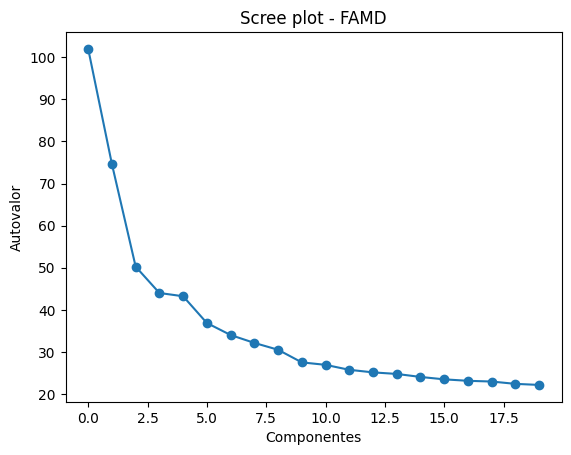

In [16]:
famd, df_used = famd_scree(
    df=modelo3,
    target="Est_Salud",
    n_components=20,
    save_path="scree_plot_famd.png"
)

In [17]:
result = famd_final(
    df=modelo3,
    n_components=7,
    target="Est_Salud"
)


FAMD EJECUTADO CORRECTAMENTE

VARIANZA EXPLICADA:
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0            101.961         3.72%                      3.72%
1             74.618         2.72%                      6.44%
2             49.937         1.82%                      8.26%
3             43.329         1.58%                      9.84%
4             42.070         1.53%                     11.37%
5             36.257         1.32%                     12.69%
6             33.228         1.21%                     13.90%

TABLA GLOBAL (TOP 15 VARIABLES):


component,0,1,2,3,4,5,6,importance
variable,,,,,,,,
Tipo_Hogar,0.201999,0.741317,0.149984,0.144217,0.237563,0.233302,0.010093,1.718475
Est_Civil,0.246510,0.657927,0.219364,0.048251,0.023464,0.063388,0.019016,1.277919
N_Adultos,0.122003,0.629108,0.063959,0.053646,0.137458,0.187840,0.004327,1.198341
Convivencia,0.046693,0.753311,0.099826,0.002859,0.001718,0.037606,0.001759,0.943771
CCAA,0.030660,0.032067,0.075070,0.089270,0.115869,0.014319,0.571884,0.929138
Frec_Cuidado_Mayores,0.002706,0.035039,0.181309,0.252685,0.002505,0.351179,0.002497,0.827920
Cuidado_Mayores,0.001821,0.035383,0.176518,0.249556,0.000485,0.343468,0.002539,0.809769
Niv_Estud,0.107848,0.013895,0.202976,0.153032,0.238784,0.046166,0.020090,0.782791
Estrato,0.003752,0.002801,0.027416,0.085066,0.053049,0.009810,0.505043,0.686937



TOP VARIABLES POR COMPONENTE:

Componente 0


,Componente 0
variable,
Dolor,0.437413
D_Caminar,0.389630
P_musculo_esq,0.380983
D_Concentrar,0.319616
P_cardio_metab,0.314895
P_organicas,0.255154
Sev_Depresiva,0.247890
Est_Civil,0.246510
Veces_Medico_4s,0.212307



Componente 1


...

,Componente 5
variable,
Frec_Cuidado_Mayores,0.351179
Cuidado_Mayores,0.343468
Tipo_Hogar,0.233302
N_Adultos,0.187840
Tabaco,0.082236
Exp_Humo,0.068338
Est_Civil,0.063388
Niv_Estud,0.046166
Urgencias_Util,0.040320



Componente 6


,Componente 6
variable,
CCAA,0.571884
Estrato,0.505043
Dolor,0.071299
Sev_Depresiva,0.071215
Alimentacion,0.046417
Exp_Humo,0.039533
Veces_Medico_4s,0.037967
Act_Libre,0.037661
P_otros,0.030697



COORDENADAS INDIVIDUOS (preview):


component,0,1,2,3,4,5,6
0,2.172516,-8.433572,-1.363598,-5.571901,-6.894224,-2.763617,-3.747524
1,27.875047,-6.208964,4.573950,9.294055,0.908434,6.881352,-7.588174
2,8.344418,-10.433995,9.673644,-3.382381,-8.367842,4.368017,-1.562518
3,-1.279167,6.890505,9.895364,-1.754387,-8.106209,-0.942978,-7.059513
4,-6.924686,7.290159,10.593434,-3.312137,-6.648066,-1.000638,-6.748090


In [18]:
var_coords = result["var_coords"]
tabla_completa = var_coords.copy()

tabla_completa["importance"] = tabla_completa.abs().sum(axis=1)

tabla_completa = tabla_completa.sort_values("importance", ascending=False)
tabla_completa
tabla_completa.to_excel("famd_variables_completo.xlsx")

In [19]:
comp_Interpretabilidad = result["ind_coords"]
comp_Interpretabilidad

component,0,1,2,3,4,5,6
0,2.172516,-8.433572,-1.363598,-5.571901,-6.894224,-2.763617,-3.747524
1,27.875047,-6.208964,4.573950,9.294055,0.908434,6.881352,-7.588174
2,8.344418,-10.433995,9.673644,-3.382381,-8.367842,4.368017,-1.562518
3,-1.279167,6.890505,9.895364,-1.754387,-8.106209,-0.942978,-7.059513
4,-6.924686,7.290159,10.593434,-3.312137,-6.648066,-1.000638,-6.748090
...,...,...,...,...,...,...,...
20984,-8.890374,5.174151,8.651393,-3.556426,-1.285811,-6.157642,-5.006760
20985,-11.731495,-3.347963,1.940003,2.591474,2.487942,4.253132,-6.586538
20986,-9.093424,-14.179289,0.878132,-0.752001,0.143736,-4.852046,-7.472310
20987,-8.941757,-12.681184,-2.070542,3.149475,-3.359387,-2.161989,-9.672814


In [20]:
modelo3_final = comp_Interpretabilidad.copy()
modelo3_final.columns = [f"Comp{i+1}" for i in range(modelo3_final.shape[1])]

modelo3_final["Edad"] = edad.values
modelo3_final["Est_Salud"] = dependiente.values

In [21]:
print(modelo3_final.isnull().sum())
print(modelo3_final.head())

Comp1        0
Comp2        0
Comp3        0
Comp4        0
Comp5        0
Comp6        0
Comp7        0
Edad         0
Est_Salud    0
dtype: int64
       Comp1      Comp2      Comp3     Comp4     Comp5     Comp6     Comp7  \
0   2.172516  -8.433572  -1.363598 -5.571901 -6.894224 -2.763617 -3.747524   
1  27.875047  -6.208964   4.573950  9.294055  0.908434  6.881352 -7.588174   
2   8.344418 -10.433995   9.673644 -3.382381 -8.367842  4.368017 -1.562518   
3  -1.279167   6.890505   9.895364 -1.754387 -8.106209 -0.942978 -7.059513   
4  -6.924686   7.290159  10.593434 -3.312137 -6.648066 -1.000638 -6.748090   

   Edad Est_Salud  
0    75     Bueno  
1    96      Malo  
2    74      Malo  
3    79     Bueno  
4    70     Bueno  


In [22]:
# Hago predictivo sobre este modelo3_final, lo guardo
modelo3_final.reset_index(drop=True, inplace=True)
modelo3_final.to_excel("modelo_final.xlsx", index=False)

In [23]:
result = famd_final(
    df=modelo3,
    n_components=3,
    target="Est_Salud"
)


FAMD EJECUTADO CORRECTAMENTE

VARIANZA EXPLICADA:
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0            101.941         3.72%                      3.72%
1             74.299         2.71%                      6.43%
2             49.205         1.79%                      8.22%

TABLA GLOBAL (TOP 15 VARIABLES):


component,0,1,2,importance
variable,,,,
Est_Civil,0.243820,0.669336,0.189814,1.102970
Tipo_Hogar,0.199219,0.744770,0.106142,1.050130
Convivencia,0.045403,0.763787,0.085088,0.894277
N_Adultos,0.120387,0.629783,0.057295,0.807465
Dolor,0.438575,0.035737,0.007098,0.481410
D_Caminar,0.389993,0.000040,0.063589,0.453622
P_musculo_esq,0.380548,0.031388,0.000431,0.412367
Ingresos,0.063353,0.255812,0.070279,0.389444
Frec_Cuidado_Mayores,0.002453,0.041651,0.311802,0.355906



TOP VARIABLES POR COMPONENTE:

Componente 0


,Componente 0
variable,
Dolor,0.438575
D_Caminar,0.389993
P_musculo_esq,0.380548
D_Concentrar,0.321001
P_cardio_metab,0.313750
P_organicas,0.255972
Sev_Depresiva,0.248198
Est_Civil,0.243820
Veces_Medico_4s,0.213574



Componente 1


,Componente 1
variable,
Convivencia,0.763787
Tipo_Hogar,0.744770
Est_Civil,0.669336
N_Adultos,0.629783
Ingresos,0.255812
N_Menores,0.069852
Prueba_Diag_12m,0.043801
P_organicas,0.042880
Clase_Social,0.042664



Componente 2


,Componente 2
variable,
Frec_Cuidado_Mayores,0.311802
Cuidado_Mayores,0.309616
Est_Civil,0.189814
Niv_Estud,0.179759
Act_Libre,0.147135
Clase_Social,0.136375
Visita_Prof_12m,0.131024
Tipo_Hogar,0.106142
Convivencia,0.085088



COORDENADAS INDIVIDUOS (preview):


component,0,1,2
0,2.132737,8.520372,2.212401
1,27.837459,6.405054,-6.396559
2,8.117959,9.783524,-7.313107
3,-1.294089,-7.150209,-8.261761
4,-6.964883,-7.610290,-8.936160


In [24]:
var_coords = result["var_coords"]
tabla_completa_simple = var_coords.copy()

tabla_completa_simple["importance"] = tabla_completa_simple.abs().sum(axis=1)

tabla_completa_simple = tabla_completa_simple.sort_values("importance", ascending=False)
tabla_completa_simple
tabla_completa_simple.to_excel("famd_variables_simple.xlsx")

In [25]:
comp_Interpretabilidad_Simple = result["ind_coords"]
comp_Interpretabilidad_Simple

component,0,1,2
0,2.132737,8.520372,2.212401
1,27.837459,6.405054,-6.396559
2,8.117959,9.783524,-7.313107
3,-1.294089,-7.150209,-8.261761
4,-6.964883,-7.610290,-8.936160
...,...,...,...
20984,-8.987903,-5.361693,-7.796205
20985,-11.850439,3.323812,-1.162040
20986,-9.183046,14.294318,-0.906705
20987,-9.063028,12.827620,2.396994


In [26]:
import numpy as np
import pandas as pd
import prince
from collections import Counter
import os

def famd_bootstrap_stability(
    df,
    n_components=7,
    n_iterations=50,
    sample_size=0.8,
    random_state=42,
    target=None,
    show=True,
    save=False
):

    # PREPARACIÓN
    df_used = df.copy()

    if target is not None and target in df_used.columns:
        df_used = df_used.drop(columns=[target])

    sample_size = int(sample_size * len(df_used))

    eigen_bootstrap = []
    top_vars = {i: [] for i in range(n_components)}


    # BOOTSTRAP 
    for i in range(n_iterations):

        df_sample = df_used.sample(
            n=sample_size,
            replace=True,
            random_state=i
        )

        famd = prince.FAMD(
            n_components=n_components,
            n_iter=10,
            random_state=random_state
        ).fit(df_sample)

        eigen_bootstrap.append(famd.eigenvalues_)

        coords = famd.row_coordinates(df_sample)

        for col in df_sample.columns:

            if df_sample[col].nunique() <= 1:
                continue

            scores = []

            for comp in range(n_components):
                try:
                    corr = np.corrcoef(
                        pd.factorize(df_sample[col])[0],
                        coords.iloc[:, comp]
                    )[0, 1]
                except:
                    corr = 0

                scores.append(abs(corr))

            best_comp = np.argmax(scores)
            top_vars[best_comp].append(col)


    # RESULTADOS 
    eigen_bootstrap = pd.DataFrame(
        eigen_bootstrap,
        columns=[f"PC{i+1}" for i in range(n_components)]
    )

    stability_vars = {}

    for comp in range(n_components):

        counts = Counter(top_vars[comp])

        stability_vars[f"Componente {comp}"] = (
            pd.DataFrame.from_dict(
                counts,
                orient="index",
                columns=["frecuencia"]
            ).sort_values("frecuencia", ascending=False)
        )


    # OUTPUT + GRÁFICOS
    if show:

        print("\n" + "="*60)
        print("BOOTSTRAP FAMD - ESTABILIDAD GLOBAL")
        print("="*60)

        print("\nResumen autovalores:")
        print(eigen_bootstrap.describe())

        print("\n" + "="*60)
        print("ESTABILIDAD DE VARIABLES POR COMPONENTE")
        print("="*60)

        for comp in range(n_components):

            print("\n" + "-"*50)
            print(f"COMPONENTE {comp}")
            print("-"*50)

            display(stability_vars[f"Componente {comp}"].head(15))


        if save:
            os.makedirs("figuras", exist_ok=True)

        import seaborn as sns
        import matplotlib.pyplot as plt


        # BOXPLOT AUTOVALORES
        eigen_melt = eigen_bootstrap.melt(
            var_name="Componente",
            value_name="Autovalor"
        )

        plt.figure(figsize=(10,5))
        sns.boxplot(data=eigen_melt, x="Componente", y="Autovalor")
        plt.title("Bootstrap FAMD - Estabilidad de autovalores")
        plt.xticks(rotation=45)
        plt.tight_layout()

        if save:
            plt.savefig("figuras/boxplot_autovalores.png", dpi=300, bbox_inches="tight")

        plt.show()


        # BOXPLOT % VARIANZA
        var_exp = eigen_bootstrap.div(eigen_bootstrap.sum(axis=1), axis=0) * 100

        var_melt = var_exp.melt(
            var_name="Componente",
            value_name="% Varianza"
        )

        plt.figure(figsize=(10,5))
        sns.boxplot(data=var_melt, x="Componente", y="% Varianza")
        plt.title("Bootstrap FAMD - % varianza explicada")
        plt.xticks(rotation=45)
        plt.tight_layout()

        if save:
            plt.savefig("figuras/boxplot_varianza.png", dpi=300, bbox_inches="tight")

        plt.show()

    return {
        "eigen_bootstrap": eigen_bootstrap,
        "stability_vars": stability_vars
    }


BOOTSTRAP FAMD - ESTABILIDAD GLOBAL

Resumen autovalores:
              PC1        PC2        PC3        PC4        PC5        PC6  \
count   50.000000  50.000000  50.000000  50.000000  50.000000  50.000000   
mean   101.984779  74.784152  50.778887  44.694304  43.630355  37.863046   
std      1.037871   0.476742   0.510833   0.350084   0.424189   0.431879   
min     99.643712  73.513189  49.629068  43.494465  42.670402  36.517936   
25%    101.503948  74.510353  50.505702  44.469659  43.277175  37.624917   
50%    101.880515  74.796982  50.773054  44.686654  43.645978  37.930193   
75%    102.564854  75.063054  51.098327  44.860596  43.946318  38.085613   
max    105.032905  75.757418  52.404590  45.590990  44.622526  38.722561   

             PC7  
count  50.000000  
mean   35.192154  
std     0.300255  
min    34.537019  
25%    35.015697  
50%    35.219497  
75%    35.348304  
max    35.904019  

ESTABILIDAD DE VARIABLES POR COMPONENTE

-------------------------------------------

,frecuencia
D_Ver,50
Acc_Casa,50
D_Concentrar,50
D_Oir,50
P_musculo_esq,50
Urgencias_Util,50
Prueba_Diag_12m,50
Falta_ListEsp,50
P_cardio_metab,50
P_organicas,50



--------------------------------------------------
COMPONENTE 1
--------------------------------------------------


,frecuencia
Convivencia,50
N_Adultos,40
Est_Civil,25
Ingresos,24
Tipo_Hogar,23
Clase_Social,3



--------------------------------------------------
COMPONENTE 2
--------------------------------------------------


...

,frecuencia
P_otros,39
Clase_Social,33
Tabaco,29
Niv_Estud,27
Alimentacion,21
Act_Jornada,21
Exp_Humo,19
Ingresos,15
IMC,14
Estrato,8



--------------------------------------------------
COMPONENTE 5
--------------------------------------------------


,frecuencia
Cuidado_Mayores,38
Frec_Cuidado_Mayores,38
Alcohol_Fin,15
Tipo_Hogar,13
N_Adultos,9
Tabaco,7
Act_Jornada,4
Exp_Humo,3
Ingresos,1
Alcohol_Entre,1



--------------------------------------------------
COMPONENTE 6
--------------------------------------------------


,frecuencia
Estrato,37
CCAA,32
Pais_Nac,12
Alimentacion,6
Clase_Social,5
Dolor,4
Genero,4
Act_Jornada,3
Exp_Humo,3
Niv_Estud,1


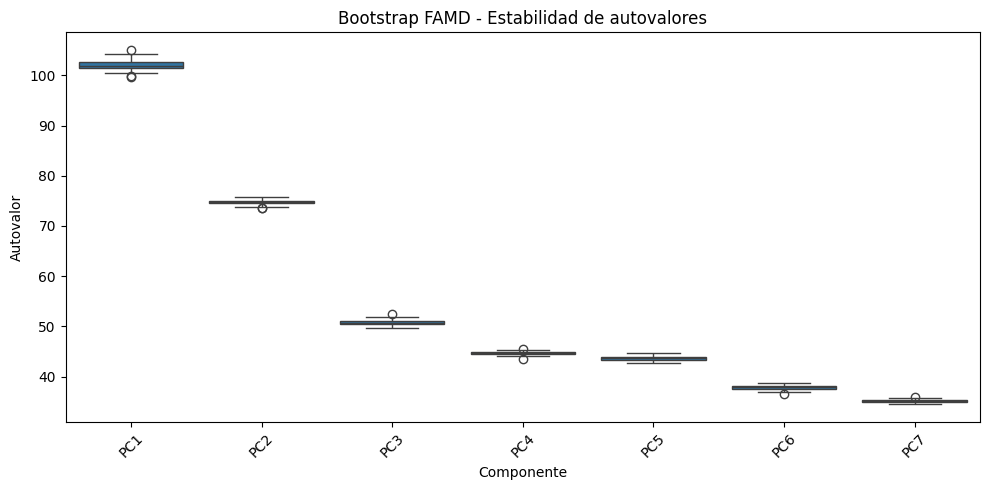

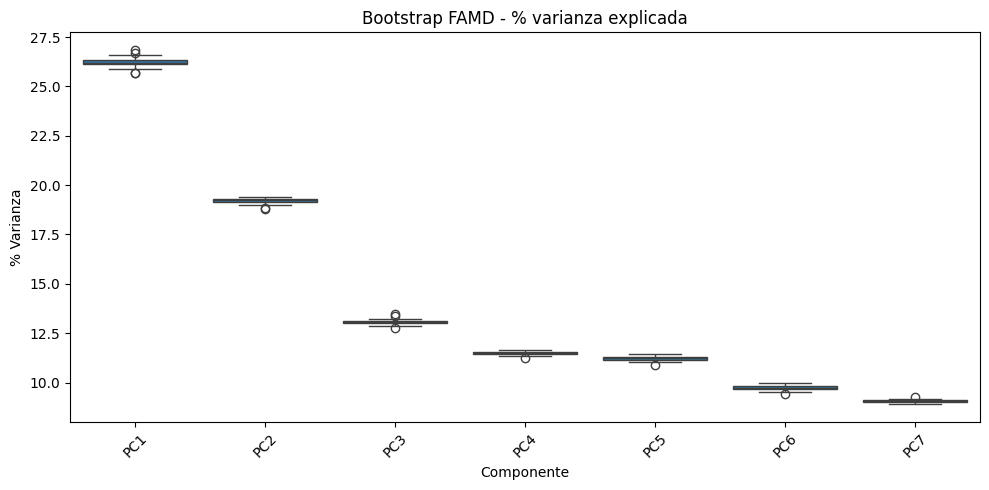

In [27]:
res_con = famd_bootstrap_stability(
    df=modelo3,
    n_components=7,
    target="Est_Salud",
    show=True,
    save=True
)

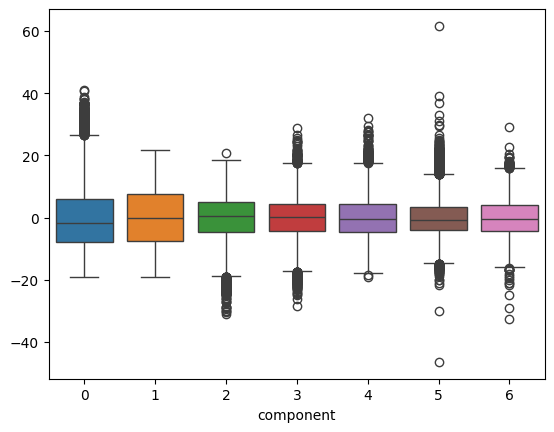

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=comp_Interpretabilidad)
plt.show()

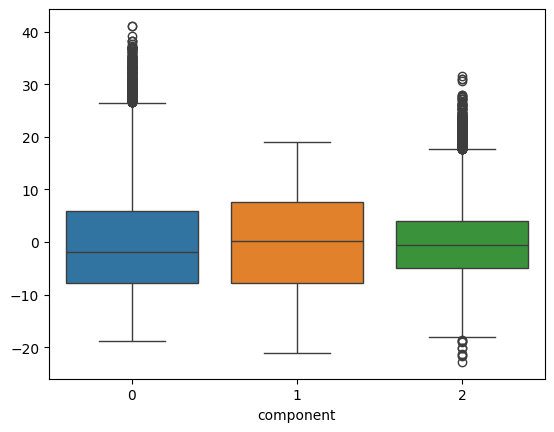

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(data=comp_Interpretabilidad_Simple)
plt.show()

In [30]:
from scipy.cluster.hierarchy import linkage

def compute_linkage_methods(X, methods=["ward", "complete", "average", "single", "centroid"]):
    Z_dict = {}

    for method in methods:

        if method == "ward":
            Z_dict[method] = linkage(X, method=method)
        else:
            Z_dict[method] = linkage(X, method=method, metric="euclidean")

    return Z_dict

In [31]:
compute_linkage_methods(comp_Interpretabilidad)

{'ward': array([[1.54500000e+03, 4.23800000e+03, 0.00000000e+00, 2.00000000e+00],
        [1.84300000e+03, 4.09500000e+03, 1.26615334e-02, 2.00000000e+00],
        [4.15800000e+03, 4.17500000e+03, 2.53230669e-02, 2.00000000e+00],
        ...,
        [4.19630000e+04, 4.19720000e+04, 1.20909538e+03, 1.09390000e+04],
        [4.19600000e+04, 4.19730000e+04, 1.26457116e+03, 1.00500000e+04],
        [4.19740000e+04, 4.19750000e+04, 1.48309176e+03, 2.09890000e+04]],
       shape=(20988, 4)),
 'complete': array([[1.54500000e+03, 4.23800000e+03, 0.00000000e+00, 2.00000000e+00],
        [1.84300000e+03, 4.09500000e+03, 1.26615334e-02, 2.00000000e+00],
        [4.15800000e+03, 4.17500000e+03, 2.53230669e-02, 2.00000000e+00],
        ...,
        [4.19720000e+04, 4.19730000e+04, 7.64756858e+01, 2.09410000e+04],
        [4.19710000e+04, 4.19740000e+04, 9.17247005e+01, 2.09880000e+04],
        [2.68900000e+03, 4.19750000e+04, 1.22433532e+02, 2.09890000e+04]],
       shape=(20988, 4)),
 'average': 

In [32]:
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram

def plot_dendrograms(X, methods=["ward", "complete", "average", "single", "centroid"], figsize=(12, 6)):

    for method in methods:
        plt.figure(figsize=figsize)

        # Ward no necesita metric
        if method == "ward":
            Z = linkage(X, method=method)
        else:
            Z = linkage(X, method=method, metric="euclidean")

        dendrogram(Z)

        plt.title(f"Dendrograma - {method.capitalize()}")
        plt.xlabel("Observaciones")
        plt.ylabel("Distancia")
        plt.show()

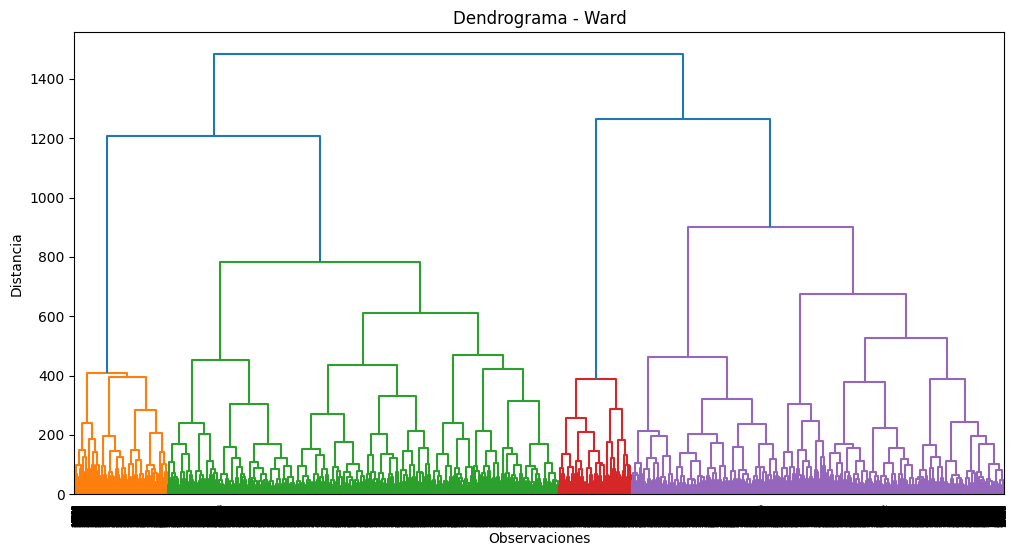

In [33]:
plot_dendrograms(comp_Interpretabilidad,methods=["ward"])

In [34]:
# plot_dendrograms(comp_Interpretabilidad,methods=["complete"])
# plot_dendrograms(comp_Interpretabilidad,methods=["average"])
# ..... (resto) --> computacionalmente costoso y se ve muy mal(tarda mucho)

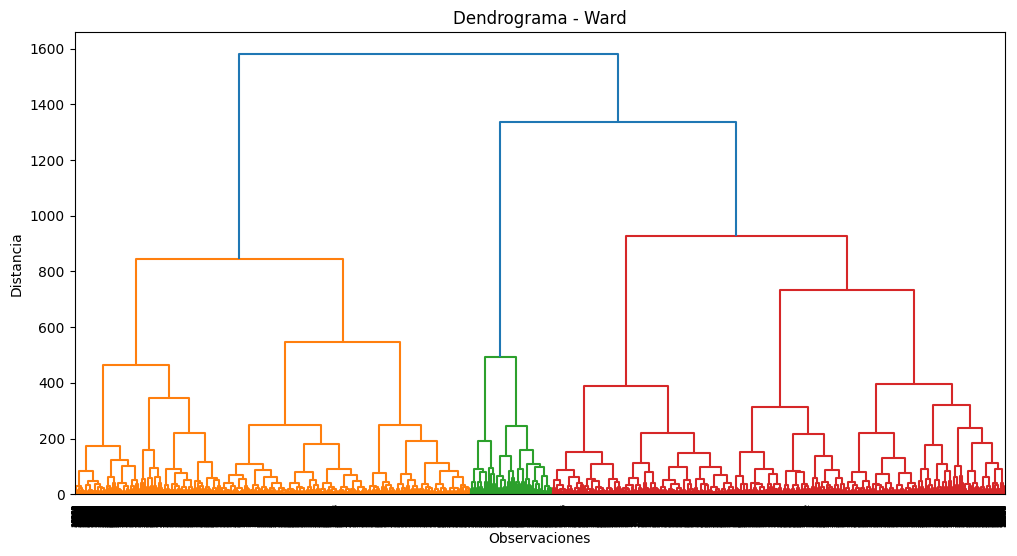

In [35]:
plot_dendrograms(comp_Interpretabilidad_Simple,methods=["ward"])

In [36]:
Z_ward = compute_linkage_methods(comp_Interpretabilidad, methods=["ward"])["ward"]
type(Z_ward)
Z_ward

array([[1.54500000e+03, 4.23800000e+03, 0.00000000e+00, 2.00000000e+00],
       [1.84300000e+03, 4.09500000e+03, 1.26615334e-02, 2.00000000e+00],
       [4.15800000e+03, 4.17500000e+03, 2.53230669e-02, 2.00000000e+00],
       ...,
       [4.19630000e+04, 4.19720000e+04, 1.20909538e+03, 1.09390000e+04],
       [4.19600000e+04, 4.19730000e+04, 1.26457116e+03, 1.00500000e+04],
       [4.19740000e+04, 4.19750000e+04, 1.48309176e+03, 2.09890000e+04]],
      shape=(20988, 4))

In [37]:
import numpy as np
import pandas as pd
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import pdist, squareform

# MÉTRICAS AUXILIARES
def pseudo_f(X, labels):
    overall_mean = np.mean(X, axis=0)
    k = len(np.unique(labels))
    n = len(X)

    ssb = 0
    ssw = 0

    for c in np.unique(labels):
        cluster = X[labels == c]
        n_c = len(cluster)
        cluster_mean = cluster.mean(axis=0)

        ssb += n_c * np.sum((cluster_mean - overall_mean) ** 2)
        ssw += np.sum((cluster - cluster_mean) ** 2)

    dfb = k - 1
    dfw = n - k

    return (ssb / dfb) / (ssw / dfw)


def rmsstd(X, labels):
    n = len(X)
    total = 0

    for c in np.unique(labels):
        cluster = X[labels == c]
        center = cluster.mean(axis=0)
        total += np.sum((cluster - center) ** 2)

    return np.sqrt(total / n)


def r2_score_clustering(X, labels):
    total_ss = np.sum((X - np.mean(X, axis=0)) ** 2)

    within_ss = 0
    for c in np.unique(labels):
        cluster = X[labels == c]
        center = cluster.mean(axis=0)
        within_ss += np.sum((cluster - center) ** 2)

    return 1 - within_ss / total_ss


def pseudo_t2(Z):
    t2 = []
    for i in range(len(Z) - 1):
        if i == 0:
            t2.append(np.nan)
        else:
            n1 = Z[i, 3]
            n2 = Z[i + 1, 3]
            d1 = Z[i, 2]
            d2 = Z[i + 1, 2]
            t2.append((d2 - d1) / (n1 + n2))
    return np.array(t2)


def centroid_distances(X, labels):
    centroids = []
    for c in np.unique(labels):
        centroids.append(X[labels == c].mean(axis=0))

    centroids = np.array(centroids)
    dist_matrix = squareform(pdist(centroids))
    
    return np.mean(dist_matrix[np.triu_indices(len(centroids), k=1)])



# PIPELINE 
def clustering_metrics(X, k_values=range(2, 9), method="ward", save_path=None):
    
    # clustering jerárquico
    Z = linkage(X, method=method)
    t2_values = pseudo_t2(Z)

    results = []

    for k in k_values:
        labels = fcluster(Z, k, criterion="maxclust")

        results.append({
            "k": k,
            "silhouette": silhouette_score(X, labels),
            "pseudo_f": pseudo_f(X, labels),
            "rmsstd": rmsstd(X, labels),
            "r2": r2_score_clustering(X, labels),
            "centroid_dist": centroid_distances(X, labels),
            "cluster_sizes": dict(pd.Series(labels).value_counts().sort_index())
        })

    df_metrics = pd.DataFrame(results)

    # EXPORT EXCEL
    if save_path is not None:
        with pd.ExcelWriter(save_path) as writer:
            df_metrics.to_excel(writer, sheet_name="metrics", index=False)

            pd.DataFrame({"pseudo_t2": t2_values}).to_excel(
                writer, sheet_name="pseudo_t2", index=False
            )

    return df_metrics, t2_values

In [38]:
df_metrics, t2 = clustering_metrics(
    comp_Interpretabilidad,
    save_path="clustering_metrics_completo.xlsx"
)

In [39]:
df_metrics, t2 = clustering_metrics(
    comp_Interpretabilidad_Simple,
    save_path="clustering_metrics_simple.xlsx"
)

In [40]:
labels_4 = fcluster(Z_ward, 4, criterion="maxclust")
comp_Interpretabilidad["cluster_4"] = labels_4

In [41]:
# Para comp_Interpretabilidad
cols = [c for c in comp_Interpretabilidad.columns]
inter_4 = comp_Interpretabilidad[cols]

summary_4 = inter_4.groupby("cluster_4").mean()
summary_4
summary_4.to_excel("summary_cluster_4.xlsx")

In [42]:
labels_3 = fcluster(Z_ward, 3, criterion="maxclust")
comp_Interpretabilidad_Simple["cluster_3"] = labels_3

In [43]:
# Para comp_Interpretabilidad_Simple
cols = [c for c in comp_Interpretabilidad_Simple.columns]
inter_3 = comp_Interpretabilidad_Simple[cols]

summary_3 = inter_3.groupby("cluster_3").mean()
summary_3
summary_3.to_excel("summary_cluster_3.xlsx")

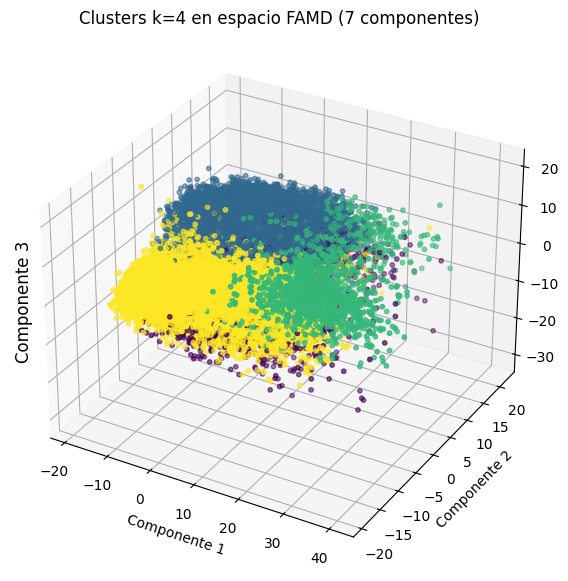

In [44]:
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    comp_Interpretabilidad[0],
    comp_Interpretabilidad[1],
    comp_Interpretabilidad[2],
    c=comp_Interpretabilidad["cluster_4"],
    cmap="viridis",
    s=10
)
ax.set_title("Clusters k=4 en espacio FAMD (7 componentes)")
ax.set_xlabel("Componente 1")
ax.set_ylabel("Componente 2")
ax.set_zlabel("")
ax.text2D(0.01, 0.5, "Componente 3", transform=ax.transAxes, 
          rotation=90, va='center', fontsize=12)
plt.savefig("clusters_7comp.png", dpi=300, bbox_inches="tight")
plt.show()

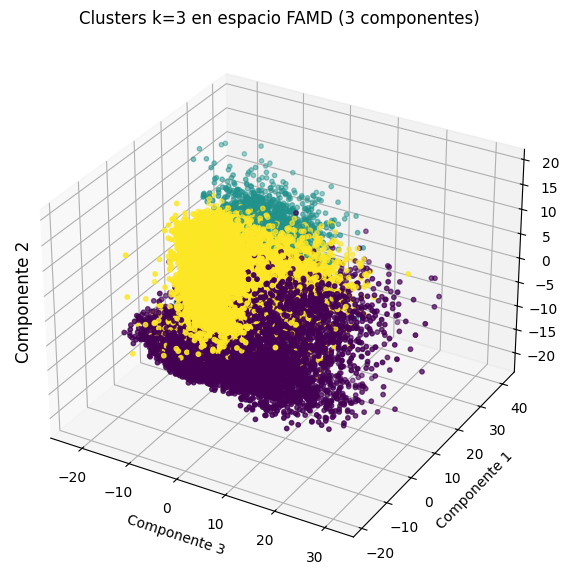

In [45]:
fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(
    comp_Interpretabilidad_Simple[2],
    comp_Interpretabilidad_Simple[0],
    comp_Interpretabilidad_Simple[1],
    c=comp_Interpretabilidad_Simple["cluster_3"],
    cmap="viridis",
    s=10
)
ax.set_title("Clusters k=3 en espacio FAMD (3 componentes)")
ax.set_xlabel("Componente 3")
ax.set_ylabel("Componente 1")
ax.set_zlabel("")
ax.text2D(0.01, 0.5, "Componente 2", transform=ax.transAxes, 
          rotation=90, va='center', fontsize=12)
plt.savefig("clusters_3_siii_comp.png", dpi=300, bbox_inches="tight")
plt.show()

In [46]:
# Para 3 componentes
print(comp_Interpretabilidad_Simple["cluster_3"].unique())
print(sorted(comp_Interpretabilidad_Simple["cluster_3"].unique()))

# Para 7 componentes
print(comp_Interpretabilidad["cluster_4"].unique())
print(sorted(comp_Interpretabilidad["cluster_4"].unique()))

[3 2 1]
[np.int32(1), np.int32(2), np.int32(3)]
[4 3 2 1]
[np.int32(1), np.int32(2), np.int32(3), np.int32(4)]


In [47]:
# Para profundizar 2 a 2, no se hace por coste computacional y porque no se ve nada claro
# Cambiar los parámetros [ ] y el nombre de los scores si se quiere ejecutar según lo deseado


#plt.figure(figsize=(7,6))
#plt.scatter(
    #comp_Interpretabilidad[0],
    #comp_Interpretabilidad[1],
    #c=comp_Interpretabilidad["cluster_4"],
    #cmap="viridis",
    #s=10
#)

#plt.title("Clusters k=4 (Comp 0 vs Comp 1)")
#plt.xlabel("Componente 0")
#plt.ylabel("Componente 1")
#plt.colorbar(label="Cluster")
#plt.show()

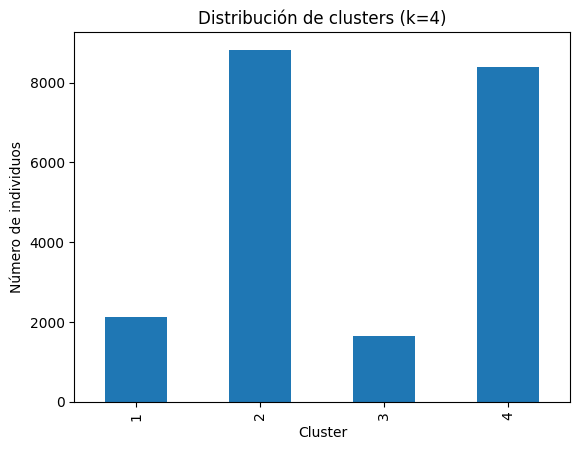

In [48]:
import pandas as pd
import matplotlib.pyplot as plt

comp_Interpretabilidad["cluster_4"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribución de clusters (k=4)")
plt.xlabel("Cluster")
plt.ylabel("Número de individuos")
plt.show()

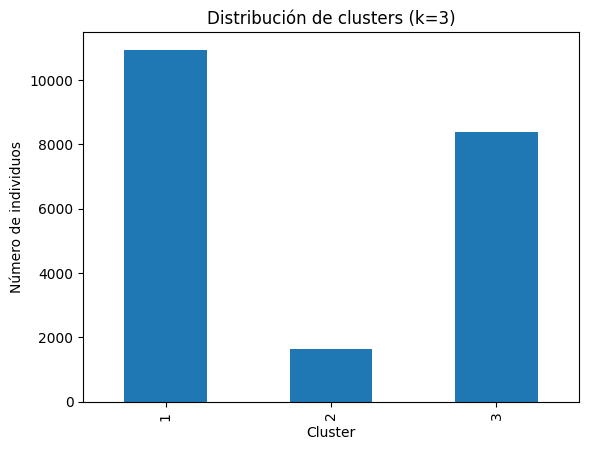

In [49]:
import pandas as pd
import matplotlib.pyplot as plt

comp_Interpretabilidad_Simple["cluster_3"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribución de clusters (k=3)")
plt.xlabel("Cluster")
plt.ylabel("Número de individuos")
plt.show()

In [50]:
comp_Interpretabilidad = comp_Interpretabilidad.copy()
comp_Interpretabilidad["edad"] = edad.values
tabla_edad = comp_Interpretabilidad.groupby("cluster_4")["edad"].describe()
tabla_edad.to_excel("edad_por_cluster_completo.xlsx")

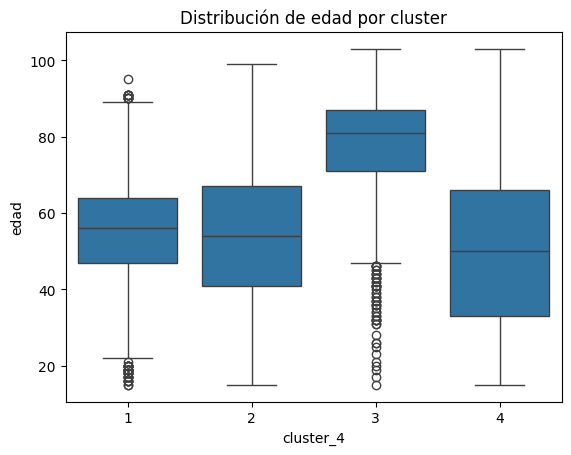

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x="cluster_4",
    y="edad",
    data=comp_Interpretabilidad
)

plt.title("Distribución de edad por cluster")

plt.savefig("boxplot_edad_por_cluster.png", dpi=300, bbox_inches="tight")

plt.show()

In [52]:
comp_Interpretabilidad_Simple = comp_Interpretabilidad_Simple.copy()
comp_Interpretabilidad_Simple["edad"] = edad.values
tabla_edad=comp_Interpretabilidad_Simple.groupby("cluster_3")["edad"].describe()
tabla_edad.to_excel("edad_por_cluster_simple.xlsx")

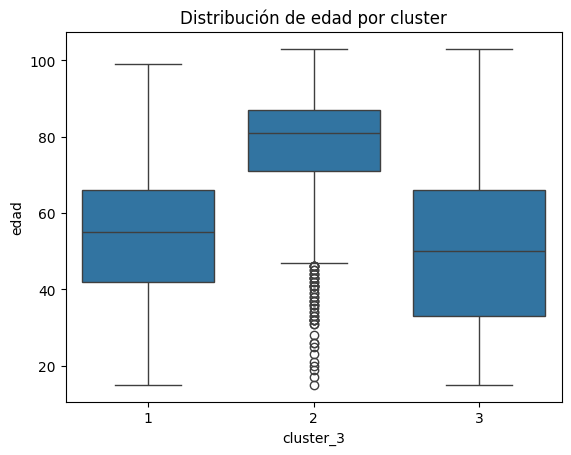

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x="cluster_3",
    y="edad",
    data=comp_Interpretabilidad_Simple
)

plt.title("Distribución de edad por cluster")

plt.savefig("boxplot_edad_por_cluster_3.png", dpi=300, bbox_inches="tight")

plt.show()

In [54]:
modelo4=modelo3
genero = modelo4["Genero"]
com_aut = modelo4["CCAA"]
modelo4 = modelo4.drop(columns=[
    "CCAA"
])
modelo4 = modelo4.drop(columns=[
    "Genero"
])

In [55]:
modelo4

,Pais_Nac,Convivencia,Est_Civil,Tipo_Hogar,N_Adultos,N_Menores,Niv_Estud,Clase_Social,Ingresos,Estrato,...,Urgencias_Util,Veces_Medico_4s,Cuidado_Mayores,Frec_Cuidado_Mayores,Dolor,P_cardio_metab,P_musculo_esq,P_organicas,P_neuro_mental,P_otros
0,España,Ninguno,Soltero,Unipersonal,1,0,FP grado medio,Trabajadores cualificados (sector primario)/Se...,"[1100,1650)",10.000-20.000,...,No,0,No,0,Leve,Sí,Sí,Sí,No,No
1,España,Ninguno,Viudo,Unipersonal,1,0,Primaria completa,Ocupaciones intermedias/Autónomos,"[1100,1650)",10.000-20.000,...,No,1,No,0,Moderado,Sí,Sí,Sí,Sí,Sí
2,España,Ninguno,Viudo,Unipersonal,1,0,Primaria completa,Trabajadores no cualificados,< 1100,10.000-20.000,...,No,0,No,0,Leve,Sí,Sí,Sí,No,No
3,España,Cónyuge,Casado,Pareja sola,2,0,Primaria completa,Supervisores/Técnicos cualificados,"[1100,1650)",10.000-20.000,...,No,1,No,0,Ninguno,Sí,No,Sí,No,Sí
4,Extranjero,Cónyuge,Casado,Pareja sola,2,0,Primaria completa,Trabajadores cualificados (sector primario)/Se...,"[2300,3800)",10.000-20.000,...,No,0,No,0,Ninguno,Sí,No,No,No,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20984,España,Cónyuge,Casado,Pareja sola,2,0,FP grado medio,Supervisores/Técnicos cualificados,"[2300,3800)",Capital provincia,...,No,1,No,0,Leve,No,No,No,No,No
20985,España,Ninguno,Casado,Pareja todos hijos ≥ 25,3,0,Bachillerato,Trabajadores cualificados (sector primario)/Se...,"[2300,3800)",Capital provincia,...,No,0,No,0,Leve,No,No,No,No,No
20986,España,Ninguno,Soltero,Unipersonal,1,0,Secundaria Inicial,Supervisores/Técnicos cualificados,"[1100,1650)",Capital provincia,...,No,0,No,0,Leve,No,No,No,No,No
20987,España,Ninguno,Soltero,Unipersonal,1,0,Bachillerato,Ocupaciones intermedias/Autónomos,"[2300,3800)",Capital provincia,...,No,0,No,0,Leve,No,No,No,No,No


Eigenvalues:
[95.5871851  70.45451333 46.93935864 40.75442591 40.1114716  34.50992619
 29.26318689 28.72981514 25.19949796 25.00917338 23.69958296 23.2230189
 22.65133992 21.64244576 21.16382845 20.76468374 20.44643785 20.36788644
 20.2344523  19.81351732]


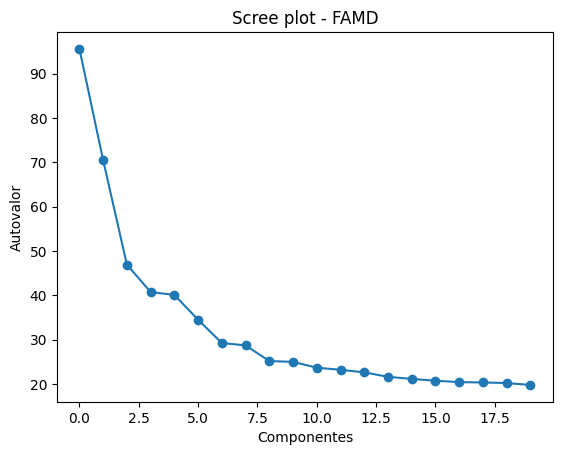

In [56]:
famd, df_used = famd_scree(
    df=modelo4,
    target="Est_Salud",
    n_components=20
)

In [57]:
result = famd_final(
    df=modelo4,
    n_components=3,
    target="Est_Salud"
)


FAMD EJECUTADO CORRECTAMENTE

VARIANZA EXPLICADA:
          eigenvalue % of variance % of variance (cumulative)
component                                                    
0             95.529         4.22%                      4.22%
1             70.184         3.10%                      7.32%
2             45.921         2.03%                      9.35%

TABLA GLOBAL (TOP 15 VARIABLES):


component,0,1,2,importance
variable,,,,
Tipo_Hogar,0.215955,0.740777,0.208535,1.165267
Est_Civil,0.246718,0.664121,0.195485,1.106324
Convivencia,0.050077,0.759421,0.085165,0.894663
N_Adultos,0.129834,0.625546,0.086584,0.841964
Dolor,0.432486,0.041348,0.011945,0.485779
D_Caminar,0.395327,0.000568,0.034418,0.430313
P_musculo_esq,0.376024,0.034688,0.000063,0.410775
Ingresos,0.068680,0.256202,0.077959,0.402841
P_cardio_metab,0.318781,0.026001,0.031957,0.376739



TOP VARIABLES POR COMPONENTE:

Componente 0


,Componente 0
variable,
Dolor,0.432486
D_Caminar,0.395327
P_musculo_esq,0.376024
D_Concentrar,0.319551
P_cardio_metab,0.318781
P_organicas,0.253661
Est_Civil,0.246718
Sev_Depresiva,0.245957
Tipo_Hogar,0.215955



Componente 1


,Componente 1
variable,
Convivencia,0.759421
Tipo_Hogar,0.740777
Est_Civil,0.664121
N_Adultos,0.625546
Ingresos,0.256202
N_Menores,0.074644
Prueba_Diag_12m,0.048230
P_organicas,0.046388
Visita_Prof_12m,0.046240



Componente 2


,Componente 2
variable,
Tipo_Hogar,0.208535
Niv_Estud,0.202400
Est_Civil,0.195485
Frec_Cuidado_Mayores,0.175436
Cuidado_Mayores,0.168745
Visita_Prof_12m,0.142632
Act_Libre,0.132745
Clase_Social,0.121691
Urgencias_Util,0.089069



COORDENADAS INDIVIDUOS (preview):


component,0,1,2
0,2.674206,-8.750944,-0.017474
1,26.894705,-5.874274,-3.705798
2,7.798353,-10.386463,-10.602742
3,-1.705807,6.466438,-10.741648
4,-6.373275,6.609202,-11.469090


In [58]:
Norte = ["Galicia","Principado de Asturias","Cantabria","País Vasco","Comunidad Foral de Navarra", "La Rioja"]
Centro = ["Comunidad de Madrid","Castilla y León","Castilla La Mancha","Extremadura"]
Mediterraneo = ["Cataluña","Comunidad Valenciana","Región de Murcia","Islas Baleares"]
Sur = ["Andalucía"]
Islas = ["Canarias"]
Ceuta_y_Melilla = ["Ceuta y Melilla"]

def agrupar(columna, nombre_grupo, valores):
    return columna.replace(valores, nombre_grupo)
    
com_aut = agrupar(com_aut, "Norte", Norte)
com_aut = agrupar(com_aut, "Centro", Centro)
com_aut = agrupar(com_aut, "Mediterraneo", Mediterraneo)
com_aut = agrupar(com_aut, "Sur", Sur)
com_aut = agrupar(com_aut, "Islas", Islas)


com_aut

0                  Norte
1                  Norte
2                  Norte
3                  Norte
4                  Norte
              ...       
20984    Ceuta y Melilla
20985    Ceuta y Melilla
20986    Ceuta y Melilla
20987    Ceuta y Melilla
20988    Ceuta y Melilla
Name: CCAA, Length: 20989, dtype: str

In [59]:
comp_modeloExtra = result["ind_coords"]
comp_modeloExtra

component,0,1,2
0,2.674206,-8.750944,-0.017474
1,26.894705,-5.874274,-3.705798
2,7.798353,-10.386463,-10.602742
3,-1.705807,6.466438,-10.741648
4,-6.373275,6.609202,-11.469090
...,...,...,...
20984,-8.341713,6.141633,-8.666323
20985,-11.087388,-2.075319,-0.622105
20986,-7.439116,-12.853950,-0.651290
20987,-7.258604,-11.208814,2.430233


In [60]:
df_Extrafinal = comp_modeloExtra.copy()
df_Extrafinal.columns = [f"Comp{i+1}" for i in range(df_Extrafinal.shape[1])]
df_Extrafinal["Sexo"] = genero.values
df_Extrafinal["Edad"] = edad.values
df_Extrafinal["CCAA"] = com_aut.values
df_Extrafinal["Est_Salud"] = dependiente.values

df_Extrafinal

,Comp1,Comp2,Comp3,Sexo,Edad,CCAA,Est_Salud
0,2.674206,-8.750944,-0.017474,Hombre,75,Norte,Bueno
1,26.894705,-5.874274,-3.705798,Mujer,96,Norte,Malo
2,7.798353,-10.386463,-10.602742,Mujer,74,Norte,Malo
3,-1.705807,6.466438,-10.741648,Mujer,79,Norte,Bueno
4,-6.373275,6.609202,-11.469090,Hombre,70,Norte,Bueno
...,...,...,...,...,...,...,...
20984,-8.341713,6.141633,-8.666323,Mujer,33,Ceuta y Melilla,Bueno
20985,-11.087388,-2.075319,-0.622105,Mujer,31,Ceuta y Melilla,Bueno
20986,-7.439116,-12.853950,-0.651290,Hombre,39,Ceuta y Melilla,Malo
20987,-7.258604,-11.208814,2.430233,Hombre,42,Ceuta y Melilla,Bueno


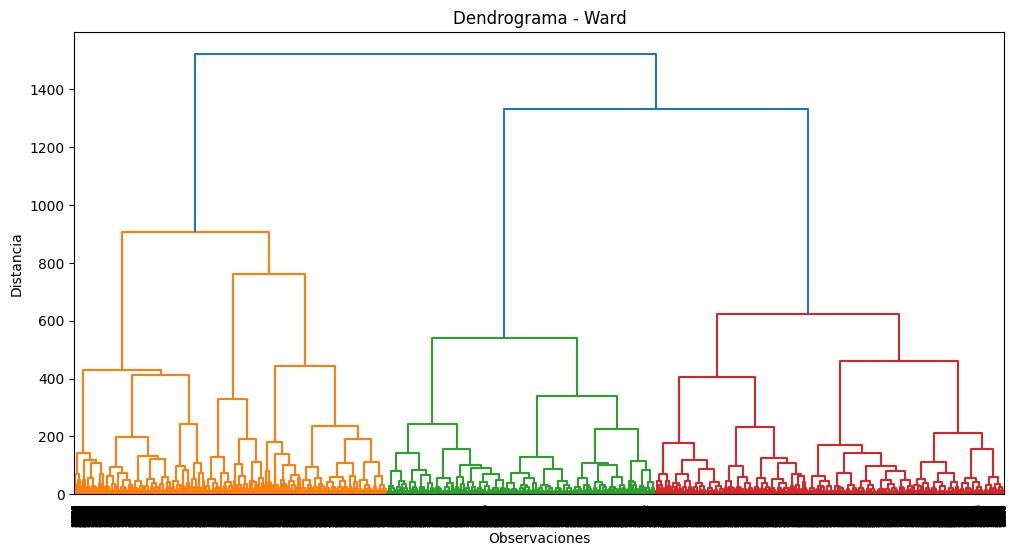

In [61]:
plot_dendrograms(comp_modeloExtra,methods=["ward"])

In [62]:
df_metrics, t2 = clustering_metrics(comp_modeloExtra)
df_metrics

,k,silhouette,pseudo_f,rmsstd,r2,centroid_dist,cluster_sizes
0,2,0.267687,7358.181418,12.542787,0.259592,15.718214,"{1: 7062, 2: 13927}"
1,3,0.290222,8884.793816,10.726453,0.458504,17.119191,"{1: 7062, 2: 6071, 3: 7856}"
2,4,0.299863,8562.398997,9.774259,0.550375,17.743805,"{1: 2948, 2: 4114, 3: 6071, 4: 7856}"
3,5,0.306671,8397.240639,9.038864,0.615487,19.298290,"{1: 2948, 2: 1323, 3: 2791, 4: 6071, 5: 7856}"
4,6,0.278021,8113.492789,8.510922,0.659093,18.790531,"{1: 2948, 2: 1323, 3: 2791, 4: 6071, 5: 3419, ..."
5,7,0.243330,7854.802404,8.090472,0.691943,18.769759,"{1: 2948, 2: 1323, 3: 2791, 4: 2661, 5: 3410, ..."
6,8,0.232707,7540.858246,7.773928,0.715577,18.514946,"{1: 2948, 2: 1323, 3: 2791, 4: 2661, 5: 3410, ..."


In [63]:
labels_5 = fcluster(Z_ward, 5, criterion="maxclust")
comp_modeloExtra["cluster_5"] = labels_5
comp_modeloExtra

component,0,1,2,cluster_5
0,2.674206,-8.750944,-0.017474,5
1,26.894705,-5.874274,-3.705798,3
2,7.798353,-10.386463,-10.602742,5
3,-1.705807,6.466438,-10.741648,2
4,-6.373275,6.609202,-11.469090,2
...,...,...,...,...
20984,-8.341713,6.141633,-8.666323,2
20985,-11.087388,-2.075319,-0.622105,4
20986,-7.439116,-12.853950,-0.651290,4
20987,-7.258604,-11.208814,2.430233,5


In [64]:
cols = [c for c in comp_modeloExtra.columns]
df_otro = comp_modeloExtra[cols]

summary_otro = df_otro.groupby("cluster_5").mean()
summary_otro

component,0,1,2
cluster_5,,,
1,0.870121,4.315747,8.327850
2,-3.147623,6.647689,-2.303975
3,19.850407,-1.834631,-2.122938
4,-7.970415,-7.821635,0.736153
5,3.877463,-7.640444,0.745525


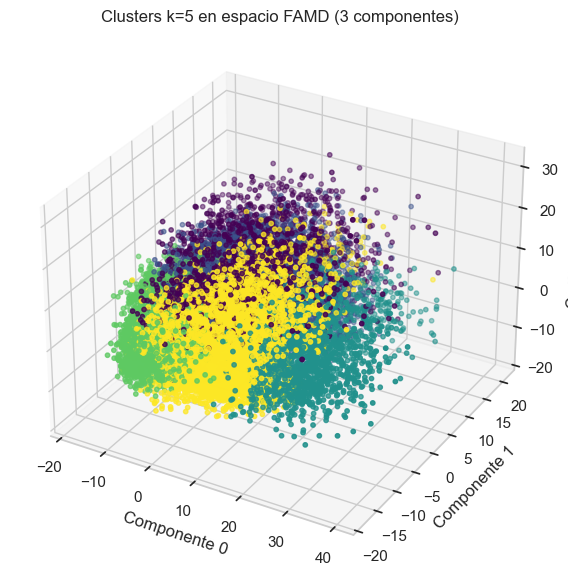

In [92]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(9,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    comp_modeloExtra[0],
    comp_modeloExtra[1],
    comp_modeloExtra[2],
    c=comp_modeloExtra["cluster_5"],
    cmap="viridis",
    s=10
)

ax.set_title("Clusters k=5 en espacio FAMD (3 componentes)")
ax.set_xlabel("Componente 0")
ax.set_ylabel("Componente 1")
ax.set_zlabel("Componente 2")

plt.show()

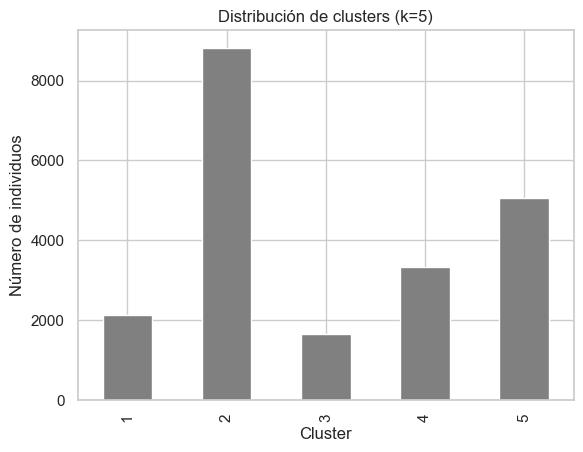

In [93]:
import pandas as pd
import matplotlib.pyplot as plt

comp_modeloExtra["cluster_5"].value_counts().sort_index().plot(kind="bar")

plt.title("Distribución de clusters (k=5)")
plt.xlabel("Cluster")
plt.ylabel("Número de individuos")
plt.show()

In [94]:
df_Extrafinal["cluster_5"] = comp_modeloExtra["cluster_5"].values
df_Extrafinal

,Comp1,Comp2,Comp3,Sexo,Edad,CCAA,Est_Salud,cluster_5
0,2.674206,-8.750944,-0.017474,Hombre,75,Norte,Bueno,5
1,26.894705,-5.874274,-3.705798,Mujer,96,Norte,Malo,3
2,7.798353,-10.386463,-10.602742,Mujer,74,Norte,Malo,5
3,-1.705807,6.466438,-10.741648,Mujer,79,Norte,Bueno,2
4,-6.373275,6.609202,-11.469090,Hombre,70,Norte,Bueno,2
...,...,...,...,...,...,...,...,...
20984,-8.341713,6.141633,-8.666323,Mujer,33,Ceuta y Melilla,Bueno,2
20985,-11.087388,-2.075319,-0.622105,Mujer,31,Ceuta y Melilla,Bueno,4
20986,-7.439116,-12.853950,-0.651290,Hombre,39,Ceuta y Melilla,Malo,4
20987,-7.258604,-11.208814,2.430233,Hombre,42,Ceuta y Melilla,Bueno,5


In [95]:
df_Extrafinal.groupby("cluster_5")["Edad"].describe()

,count,mean,std,min,25%,50%,75%,max
cluster_5,,,,,,,,
1,2115.0,55.297400,13.981741,15.0,47.0,56.0,64.0,95.0
2,8824.0,54.132706,16.674459,15.0,41.0,54.0,67.0,99.0
3,1654.0,77.388755,13.628931,15.0,71.0,81.0,87.0,103.0
4,3330.0,36.714114,15.683313,15.0,23.0,34.0,48.0,92.0
5,5066.0,58.973549,18.190993,15.0,46.0,61.0,73.0,103.0


In [96]:
pd.crosstab(df_Extrafinal["cluster_5"], df_Extrafinal["CCAA"], normalize="index")

CCAA,Aragón,Centro,Ceuta y Melilla,Islas,Mediterraneo,Norte,Sur
cluster_5,,,,,,,
1,0.049645,0.201418,0.006147,0.046809,0.278014,0.314894,0.103073
2,0.051677,0.262239,0.017112,0.038871,0.259973,0.235494,0.134633
3,0.043531,0.236397,0.012696,0.052600,0.260580,0.255139,0.139057
4,0.039940,0.252252,0.038739,0.048649,0.297898,0.161562,0.160961
5,0.054678,0.269443,0.022503,0.036123,0.257797,0.260758,0.098697


In [97]:
pd.crosstab(df_Extrafinal["cluster_5"], df_Extrafinal["Sexo"], normalize="index")

Sexo,Hombre,Mujer
cluster_5,,
1,0.421277,0.578723
2,0.498187,0.501813
3,0.197703,0.802297
4,0.579880,0.420120
5,0.416700,0.583300


In [98]:
pd.crosstab(df_Extrafinal["cluster_5"], df_Extrafinal["Est_Salud"], normalize="index")

Est_Salud,Bueno,Malo
cluster_5,,
1,0.629787,0.370213
2,0.709769,0.290231
3,0.124547,0.875453
4,0.925826,0.074174
5,0.630280,0.369720


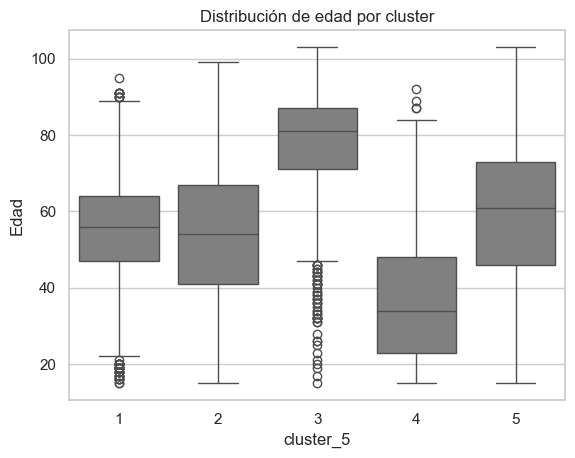

In [99]:
# Solo parece aportar Edad, vamos a ver su distribución
import seaborn as sns
import matplotlib.pyplot as plt

sns.boxplot(
    x="cluster_5",
    y="Edad",
    data=df_Extrafinal
)

plt.title("Distribución de edad por cluster")
plt.show()